# Multigraph Algorithm Analysis

## Overview
This notebook analyzes the performance and accuracy of algorithms designed for the **Multigraph Subgraph Extension Problem**.

### Problem Statement
Given a pattern graph $G$ and a host graph $H$, we want to find if $G \subseteq H$. If not, we want to find a **minimal extension** $H'$ of $H$ such that $G \subseteq H'$, minimizing the number of added edges (the "cost").

### Algorithms Tested
1.  **Exact Algorithm**: Uses a Branch & Bound approach to find the optimal extension with minimum cost. It guarantees the best solution but has exponential time complexity.
2.  **Approximate Algorithm**: Uses a heuristic based on the Hungarian algorithm (linear assignment) to find a "good enough" mapping and extension. It is much faster but may not find the optimal cost.

### Experiments
We analyze three key aspects:
1.  **Accuracy**: How close is the Approximate solution to the Exact solution? (Approximation Ratio)
2.  **Scalability**: How does the runtime of the Approximate algorithm grow with graph size?
3.  **Density Impact**: How does graph density affect the heuristic's performance?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from IPython.display import Image, display

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## Load Latest Experiment Data

In [3]:
# Find latest experiment folder
exp_dirs = glob.glob("experiments/exp_*")
latest_exp = max(exp_dirs, key=os.path.getmtime)
print(f"Loading data from: {latest_exp}")

df = pd.read_csv(os.path.join(latest_exp, "results.csv"))
df.head()

Loading data from: experiments/exp_20251202_165434


,experiment,algorithm,size_G,size_H,n_mappings,density,time,cost
0,cost_vs_n,approx,5,25,1,0.3,130.779028,1
1,cost_vs_n,approx,5,25,2,0.3,128.313541,4
2,cost_vs_n,approx,5,25,3,0.3,135.493994,4
3,cost_vs_n,approx,5,25,4,0.3,126.961946,7
4,cost_vs_n,approx,5,25,5,0.3,132.739544,7


## 1. Accuracy Analysis (Exact vs Approx)

We compare the **Minimal Extension Cost** (number of edges added) found by the Approximate algorithm against the optimal cost found by the Exact algorithm.

### Metric: Approximation Ratio
$$ \text{Ratio} = \frac{\text{Cost}_{\text{Approx}}}{\text{Cost}_{\text{Exact}}} $$

*   **Ratio = 1.0**: The Approximate algorithm found the optimal solution.
*   **Ratio > 1.0**: The Approximate algorithm added more edges than necessary (suboptimal).
*   **Ratio < 1.0**: Impossible (since Exact is optimal).

*Note: If Exact Cost is 0 (perfect subgraph found), we define the ratio as 1.0 if Approx also found it, or penalize it if it didn't.*

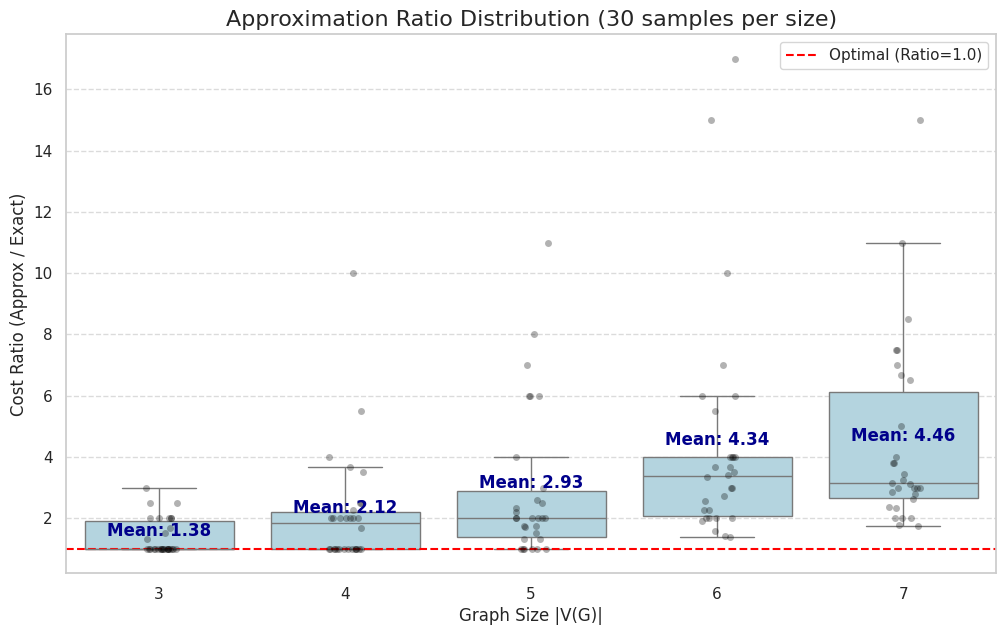

In [6]:
acc_df = df[df['experiment'] == 'accuracy'].copy()

# Calculate Ratio
acc_df['cost_ratio'] = acc_df.apply(lambda row: row['approx_cost'] / row['exact_cost'] if row['exact_cost'] > 0 else (1.0 if row['approx_cost'] == 0 else 2.0), axis=1)

plt.figure(figsize=(12, 7))

# Boxplot to show statistical distribution
sns.boxplot(data=acc_df, x='size_G', y='cost_ratio', color='lightblue', showfliers=False)
sns.stripplot(data=acc_df, x='size_G', y='cost_ratio', color='black', alpha=0.3, jitter=True)

plt.axhline(1.0, color='red', linestyle='--', label="Optimal (Ratio=1.0)")

# Calculate and display mean ratio per size
means = acc_df.groupby('size_G')['cost_ratio'].mean()
for size, mean_val in means.items():
    # Adjust x-coordinate (size starts at 3, so index is size-3)
    plt.text(size-3, mean_val + 0.05, f"Mean: {mean_val:.2f}", ha='center', color='darkblue', fontweight='bold')

plt.title("Approximation Ratio Distribution (30 samples per size)", fontsize=16)
plt.ylabel("Cost Ratio (Approx / Exact)", fontsize=12)
plt.xlabel("Graph Size |V(G)|", fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Scalability Analysis

We compare the runtime scaling of the **Exact** and **Approximate** algorithms.
*   **Exact**: Tested on sizes 3 to 9. We expect exponential growth.
*   **Approx**: Tested on sizes 5 to 50. We expect polynomial growth.
*   **Visualization**: Log-scale Y-axis to clearly show the divergence in complexity classes.

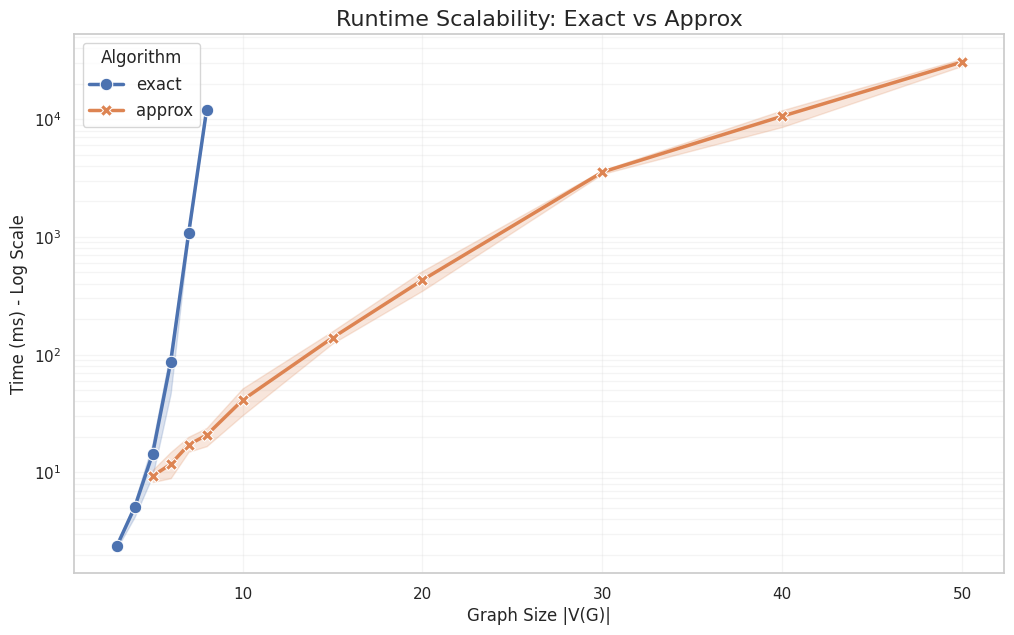

In [7]:
scale_df = df[df['experiment'] == 'scalability']

plt.figure(figsize=(12, 7))

# Plot both algorithms
sns.lineplot(data=scale_df, x='size_G', y='time', hue='algorithm', style='algorithm', markers=True, dashes=False, linewidth=2.5, markersize=9)

plt.title("Runtime Scalability: Exact vs Approx", fontsize=16)
plt.ylabel("Time (ms) - Log Scale", fontsize=12)
plt.xlabel("Graph Size |V(G)|", fontsize=12)
plt.yscale('log') 

# Annotate the crossover or divergence
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Algorithm", fontsize=12)
plt.show()

## 3. Density Impact Analysis

We investigate how the **Edge Density** of the graphs affects the runtime of both algorithms.
*   **Exact Algorithm**: Tested on small graphs ($|V(G)|=7$).
*   **Approx Algorithm**: Tested on medium ($|V(G)|=15$) and large ($|V(G)|=30$) graphs.
*   **Density Range**: $0.1$ (Sparse) to $0.9$ (Dense).

*Hypothesis*: 
*   **Exact**: Higher density might increase pruning effectiveness (faster) or increase the search space of edges (slower).
*   **Approx**: Higher density increases the complexity of the matching cost calculation but might provide more "signal" for the heuristic.

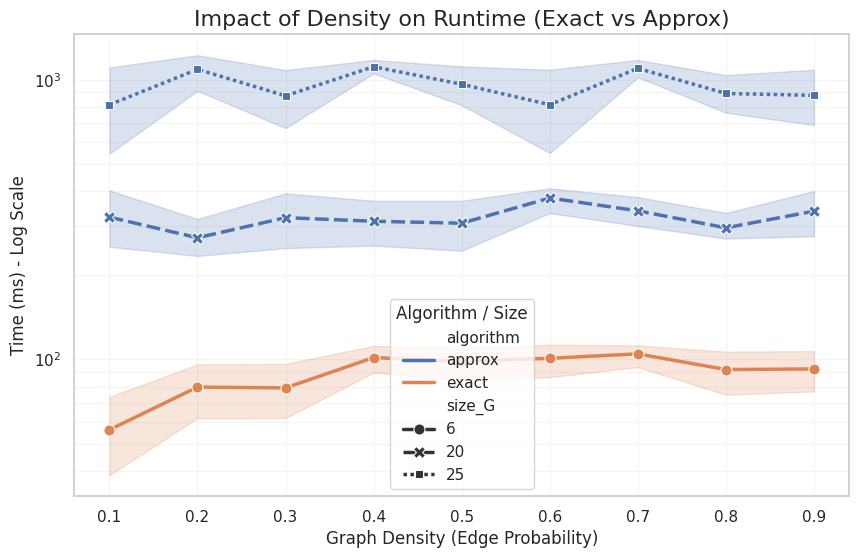

In [8]:
dens_df = df[df['experiment'] == 'density']

plt.figure(figsize=(10, 6))
# Use 'time' as y-axis, distinguish by algorithm (hue) and graph size (style)
sns.lineplot(data=dens_df, x='density', y='time', hue='algorithm', style='size_G', markers=True, linewidth=2.5, markersize=8)

plt.title("Impact of Density on Runtime (Exact vs Approx)", fontsize=16)
plt.ylabel("Time (ms) - Log Scale", fontsize=12)
plt.xlabel("Graph Density (Edge Probability)", fontsize=12)
plt.yscale('log') # Log scale is essential due to Exact's complexity
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Algorithm / Size")
plt.show()

## 4. Qualitative Visualization

We visualize a specific test case ($|V(G)|=7$) to compare the solutions found by both algorithms.
*   **Pattern Graph G**: The graph we want to embed.
*   **Host Graph H**: The target graph.
*   **Exact Extension**: The optimal set of edges added to H to contain G.
*   **Approx Extension**: The set of edges added by the heuristic.

*Legend*:
*   **Black Lines**: Original edges of H.
*   **Red Dashed Lines**: New edges added by the algorithm.

Visual Comparison of Extensions (Red Dashed Lines = Added Edges)


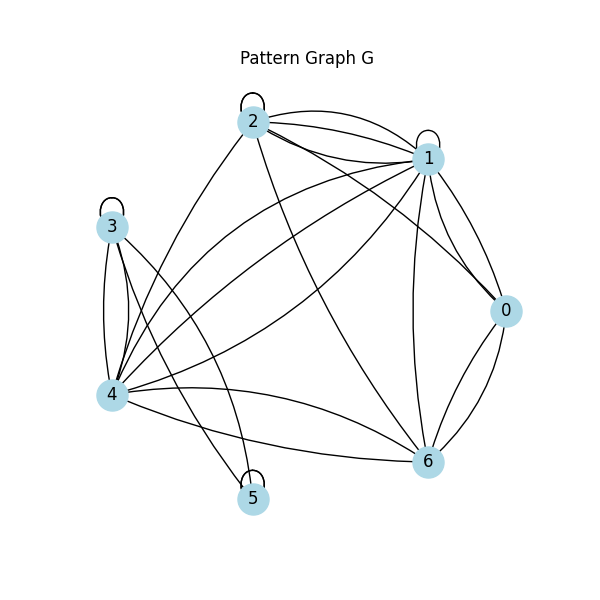

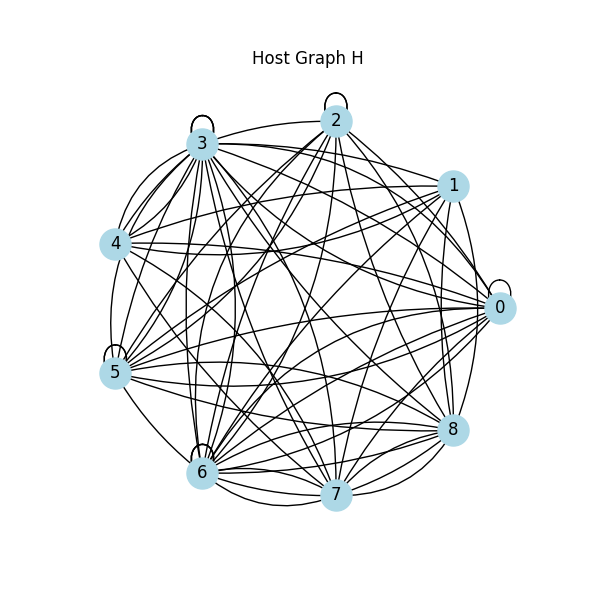

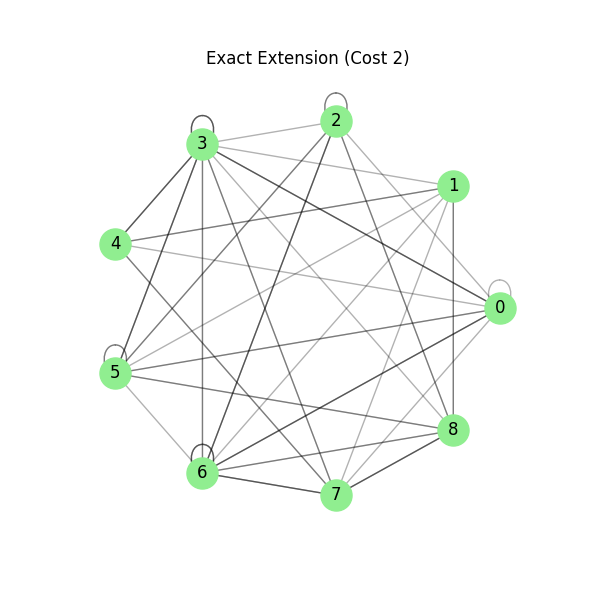

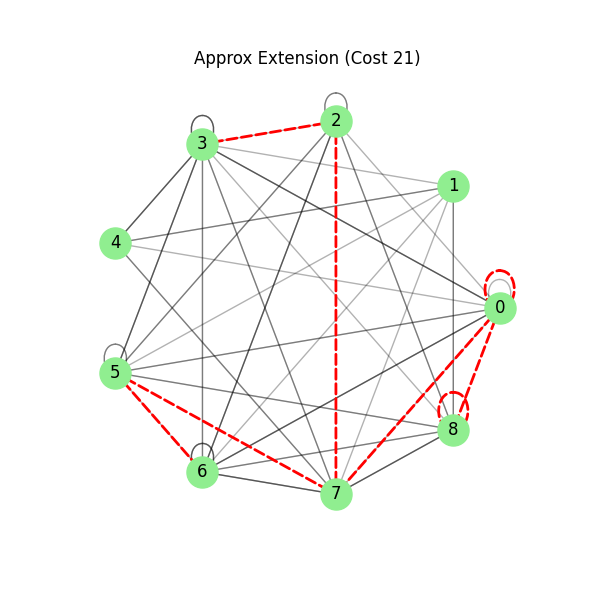

In [9]:
viz_dir = os.path.join(latest_exp, "visualizations")

# Display Comparison Images
print("Visual Comparison of Extensions (Red Dashed Lines = Added Edges)")
comp_images = ["comparison_G.png", "comparison_H.png", "comparison_Exact.png", "comparison_Approx.png"]

for img_name in comp_images:
    path = os.path.join(viz_dir, img_name)
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f"Image not found: {img_name}")

## 5. Cost vs N: Simultaneous Embeddings Analysis

This experiment tests the core feature of the algorithm: **demanding N simultaneous vertex-disjoint embeddings** of G into H.

### Key Questions:
1. How does the extension cost grow as N increases?
2. Is the growth linear, polynomial, or exponential?
3. How does graph density affect this relationship?

### Setup:
- **Pattern Graph G**: 5 vertices (Approx) / 4 vertices (Exact)
- **Host Graph H**: 25 vertices (Approx) / 12 vertices (Exact)
- **N Range**: 1 to 5 (Approx) / 1 to 3 (Exact)
- **Densities**: 0.3, 0.5, 0.7

In [4]:
# Filter Cost vs N data
cost_n_df = df[df['experiment'] == 'cost_vs_n'].copy()

if len(cost_n_df) > 0:
    print(f"Cost vs N data: {len(cost_n_df)} records")
    print(f"Densities: {cost_n_df['density'].unique()}")
    print(f"N values: {sorted(cost_n_df['n_mappings'].unique())}")
    print(f"Algorithms: {cost_n_df['algorithm'].unique()}")
else:
    print("No cost_vs_n data found. Run: make run ARGS='cost_vs_n'")

Cost vs N data: 178 records
Densities: [0.3 0.5 0.7]
N values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Algorithms: ['approx' 'exact']


### 5.1 Cost Growth by Density

How does the extension cost scale with N for different graph densities?

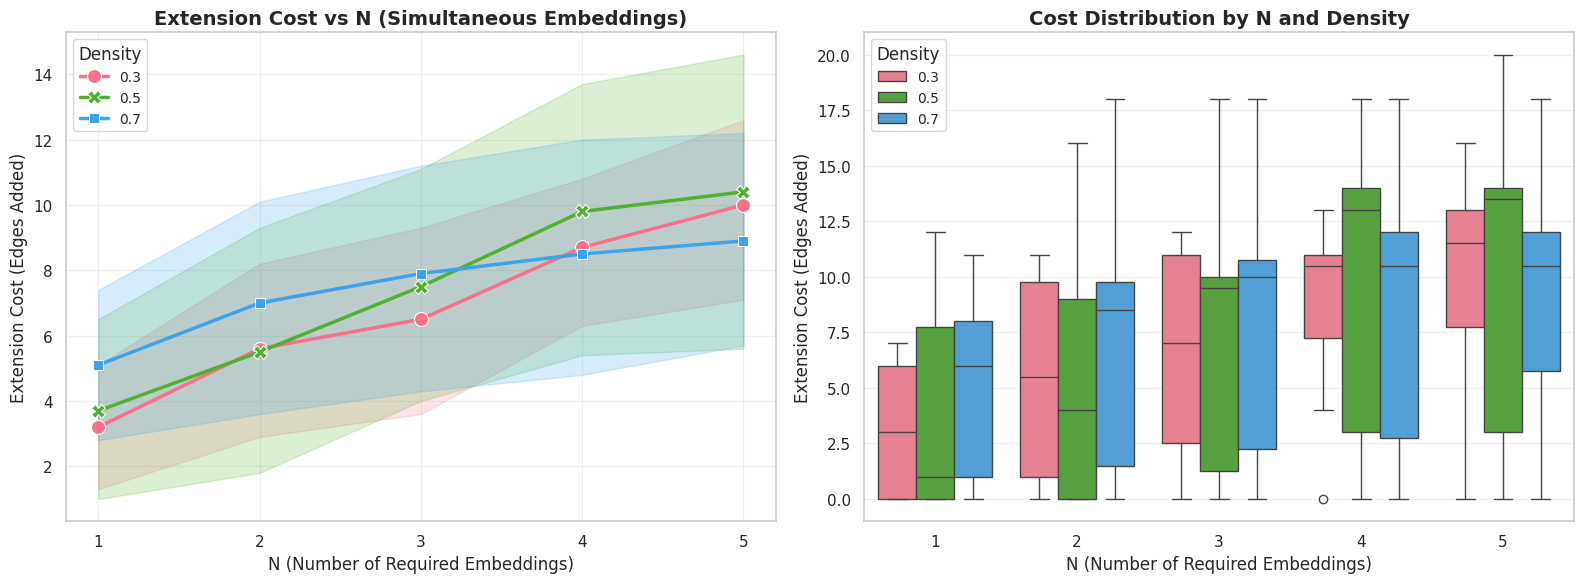

In [5]:
if len(cost_n_df) > 0:
    # Main visualization: Cost vs N for different densities
    approx_df = cost_n_df[cost_n_df['algorithm'] == 'approx']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Line plot with confidence intervals
    ax1 = axes[0]
    palette = sns.color_palette("husl", n_colors=len(approx_df['density'].unique()))
    
    sns.lineplot(data=approx_df, x='n_mappings', y='cost', hue='density', 
                 style='density', markers=True, dashes=False, 
                 linewidth=2.5, markersize=10, palette=palette, ax=ax1,
                 err_style='band', errorbar=('ci', 95))
    
    ax1.set_title("Extension Cost vs N (Simultaneous Embeddings)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
    ax1.set_ylabel("Extension Cost (Edges Added)", fontsize=12)
    ax1.legend(title="Density", fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(sorted(approx_df['n_mappings'].unique()))
    
    # Right plot: Box plot showing variance
    ax2 = axes[1]
    sns.boxplot(data=approx_df, x='n_mappings', y='cost', hue='density', 
                palette=palette, ax=ax2)
    
    ax2.set_title("Cost Distribution by N and Density", fontsize=14, fontweight='bold')
    ax2.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
    ax2.set_ylabel("Extension Cost (Edges Added)", fontsize=12)
    ax2.legend(title="Density", fontsize=10)
    ax2.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for this visualization.")

### 5.2 Marginal Cost Analysis

The **marginal cost** is the additional cost incurred when increasing N by 1. This reveals whether embedding difficulty grows linearly or accelerates.

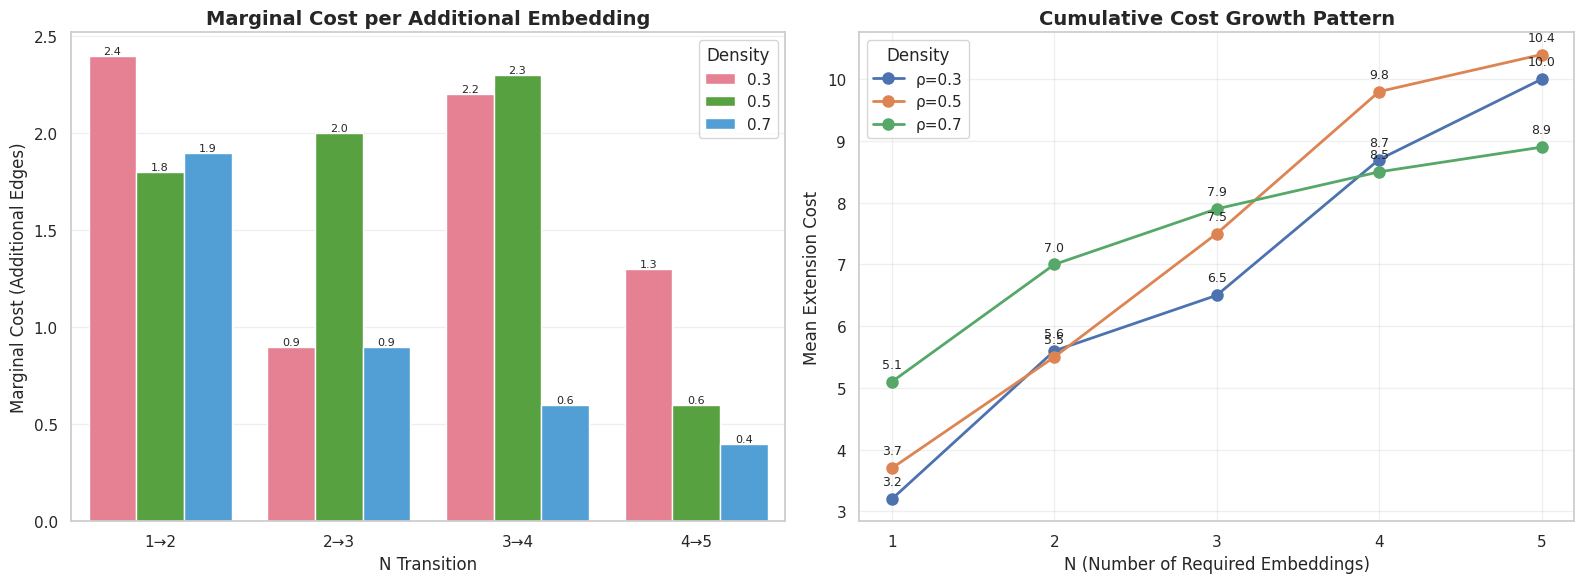

In [6]:
if len(cost_n_df) > 0:
    approx_df = cost_n_df[cost_n_df['algorithm'] == 'approx']
    
    # Calculate mean cost per (density, n_mappings)
    mean_costs = approx_df.groupby(['density', 'n_mappings'])['cost'].mean().reset_index()
    
    # Calculate marginal cost (difference from previous N)
    marginal_data = []
    for density in mean_costs['density'].unique():
        density_df = mean_costs[mean_costs['density'] == density].sort_values('n_mappings')
        costs = density_df['cost'].values
        n_vals = density_df['n_mappings'].values
        
        for i in range(1, len(costs)):
            marginal_data.append({
                'density': density,
                'n_transition': f"{n_vals[i-1]}→{n_vals[i]}",
                'n_to': n_vals[i],
                'marginal_cost': costs[i] - costs[i-1]
            })
    
    marginal_df = pd.DataFrame(marginal_data)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Bar chart of marginal costs
    ax1 = axes[0]
    palette = sns.color_palette("husl", n_colors=len(marginal_df['density'].unique()))
    
    sns.barplot(data=marginal_df, x='n_transition', y='marginal_cost', hue='density',
                palette=palette, ax=ax1)
    
    ax1.set_title("Marginal Cost per Additional Embedding", fontsize=14, fontweight='bold')
    ax1.set_xlabel("N Transition", fontsize=12)
    ax1.set_ylabel("Marginal Cost (Additional Edges)", fontsize=12)
    ax1.legend(title="Density")
    ax1.grid(True, axis='y', alpha=0.3)
    
    # Add value labels on bars
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.1f', fontsize=8)
    
    # Right: Cumulative cost growth pattern
    ax2 = axes[1]
    
    for density in mean_costs['density'].unique():
        density_df = mean_costs[mean_costs['density'] == density].sort_values('n_mappings')
        ax2.plot(density_df['n_mappings'], density_df['cost'], 
                 marker='o', linewidth=2, markersize=8, label=f"ρ={density}")
        
        # Add value annotations
        for _, row in density_df.iterrows():
            ax2.annotate(f"{row['cost']:.1f}", 
                        (row['n_mappings'], row['cost']),
                        textcoords="offset points", xytext=(0, 10),
                        ha='center', fontsize=9)
    
    ax2.set_title("Cumulative Cost Growth Pattern", fontsize=14, fontweight='bold')
    ax2.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
    ax2.set_ylabel("Mean Extension Cost", fontsize=12)
    ax2.legend(title="Density")
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(sorted(mean_costs['n_mappings'].unique()))
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for this visualization.")

### 5.3 Exact vs Approximate Comparison

Compare the solutions found by both algorithms for the same N values.

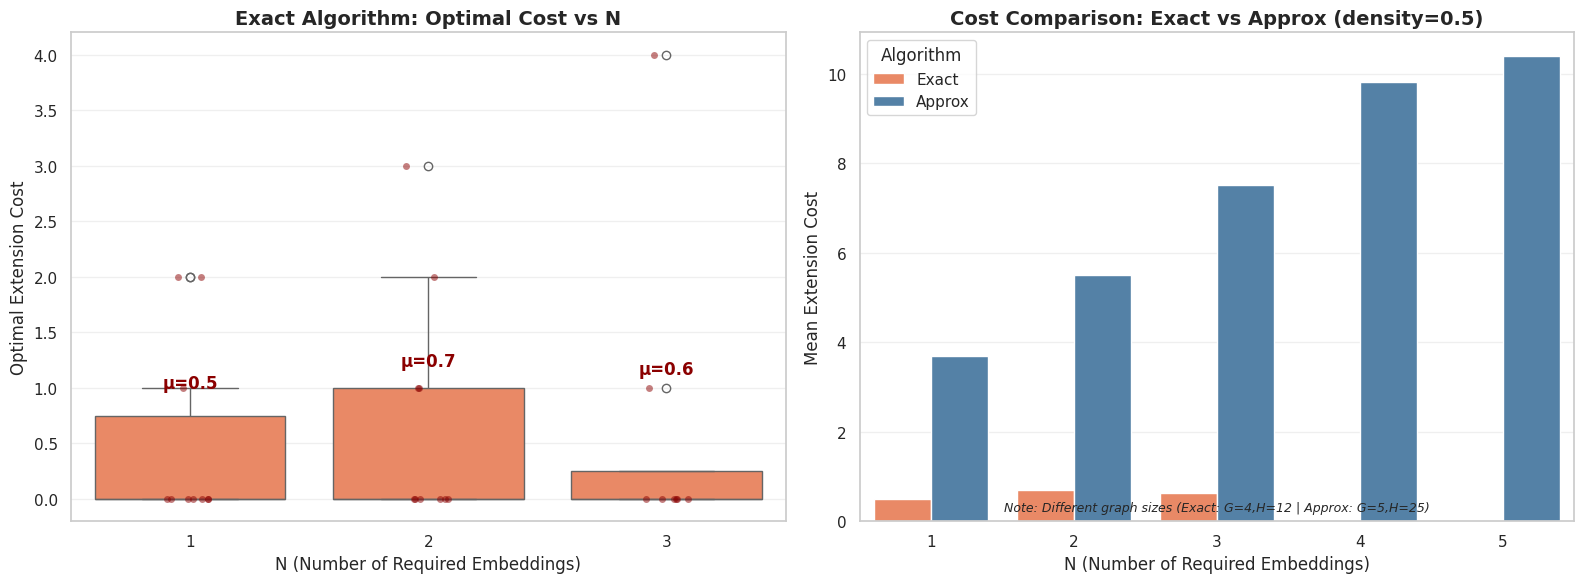

In [7]:
if len(cost_n_df) > 0:
    exact_df = cost_n_df[cost_n_df['algorithm'] == 'exact']
    approx_df_05 = cost_n_df[(cost_n_df['algorithm'] == 'approx') & (cost_n_df['density'] == 0.5)]
    
    if len(exact_df) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Left: Exact algorithm cost vs N
        ax1 = axes[0]
        sns.boxplot(data=exact_df, x='n_mappings', y='cost', color='coral', ax=ax1)
        sns.stripplot(data=exact_df, x='n_mappings', y='cost', color='darkred', alpha=0.5, ax=ax1)
        
        ax1.set_title("Exact Algorithm: Optimal Cost vs N", fontsize=14, fontweight='bold')
        ax1.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
        ax1.set_ylabel("Optimal Extension Cost", fontsize=12)
        ax1.grid(True, axis='y', alpha=0.3)
        
        # Calculate and show means
        means = exact_df.groupby('n_mappings')['cost'].mean()
        for i, (n, mean_val) in enumerate(means.items()):
            ax1.text(i, mean_val + 0.5, f"μ={mean_val:.1f}", ha='center', fontweight='bold', color='darkred')
        
        # Right: Side-by-side comparison at density=0.5
        ax2 = axes[1]
        
        # Aggregate for comparison (use overlapping N values)
        exact_means = exact_df.groupby('n_mappings')['cost'].agg(['mean', 'std']).reset_index()
        exact_means['algorithm'] = 'Exact'
        
        if len(approx_df_05) > 0:
            # For fair comparison, we need approx data at density=0.5
            # But approx uses different graph sizes, so we compare trends
            approx_means = approx_df_05.groupby('n_mappings')['cost'].agg(['mean', 'std']).reset_index()
            approx_means['algorithm'] = 'Approx'
            
            comparison_df = pd.concat([exact_means, approx_means])
            
            sns.barplot(data=comparison_df, x='n_mappings', y='mean', hue='algorithm',
                       palette=['coral', 'steelblue'], ax=ax2)
            
            ax2.set_title("Cost Comparison: Exact vs Approx (density=0.5)", fontsize=14, fontweight='bold')
            ax2.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
            ax2.set_ylabel("Mean Extension Cost", fontsize=12)
            ax2.legend(title="Algorithm")
            ax2.grid(True, axis='y', alpha=0.3)
            
            # Note about different graph sizes
            ax2.text(0.5, 0.02, "Note: Different graph sizes (Exact: G=4,H=12 | Approx: G=5,H=25)",
                    transform=ax2.transAxes, fontsize=9, style='italic', ha='center')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No exact algorithm data available.")
else:
    print("No data available for this visualization.")

### 5.4 Runtime vs N

How does the algorithm runtime scale with increasing N?

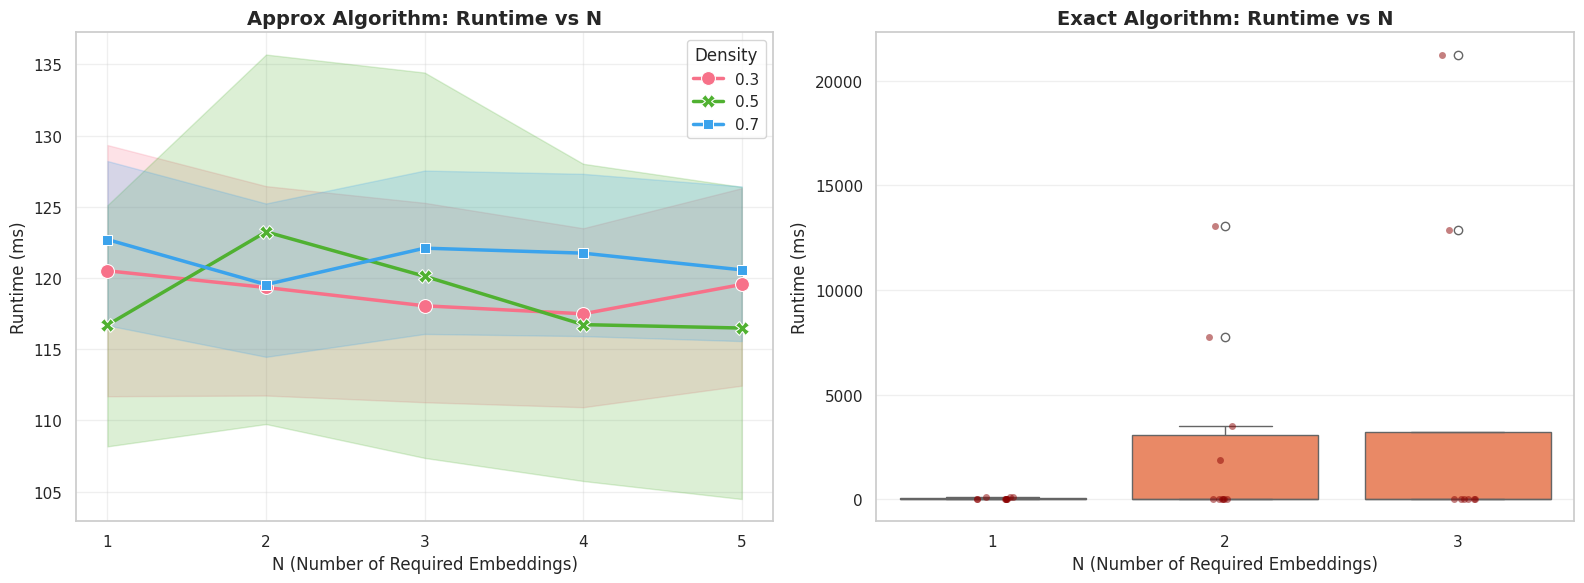

In [8]:
if len(cost_n_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Approx runtime vs N
    ax1 = axes[0]
    approx_df = cost_n_df[cost_n_df['algorithm'] == 'approx']
    
    palette = sns.color_palette("husl", n_colors=len(approx_df['density'].unique()))
    sns.lineplot(data=approx_df, x='n_mappings', y='time', hue='density',
                 style='density', markers=True, dashes=False,
                 linewidth=2.5, markersize=10, palette=palette, ax=ax1,
                 err_style='band', errorbar=('ci', 95))
    
    ax1.set_title("Approx Algorithm: Runtime vs N", fontsize=14, fontweight='bold')
    ax1.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
    ax1.set_ylabel("Runtime (ms)", fontsize=12)
    ax1.legend(title="Density")
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(sorted(approx_df['n_mappings'].unique()))
    
    # Right: Exact runtime vs N (if available)
    ax2 = axes[1]
    exact_df = cost_n_df[cost_n_df['algorithm'] == 'exact']
    
    if len(exact_df) > 0:
        sns.boxplot(data=exact_df, x='n_mappings', y='time', color='coral', ax=ax2)
        sns.stripplot(data=exact_df, x='n_mappings', y='time', color='darkred', alpha=0.5, ax=ax2)
        
        ax2.set_title("Exact Algorithm: Runtime vs N", fontsize=14, fontweight='bold')
        ax2.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
        ax2.set_ylabel("Runtime (ms)", fontsize=12)
        ax2.grid(True, axis='y', alpha=0.3)
    else:
        ax2.text(0.5, 0.5, "No Exact data available", ha='center', va='center',
                transform=ax2.transAxes, fontsize=14)
        ax2.set_title("Exact Algorithm: Runtime vs N", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for this visualization.")

### 5.5 Heatmap: Cost by N and Density

A 2D view showing how both N and density jointly affect the extension cost.

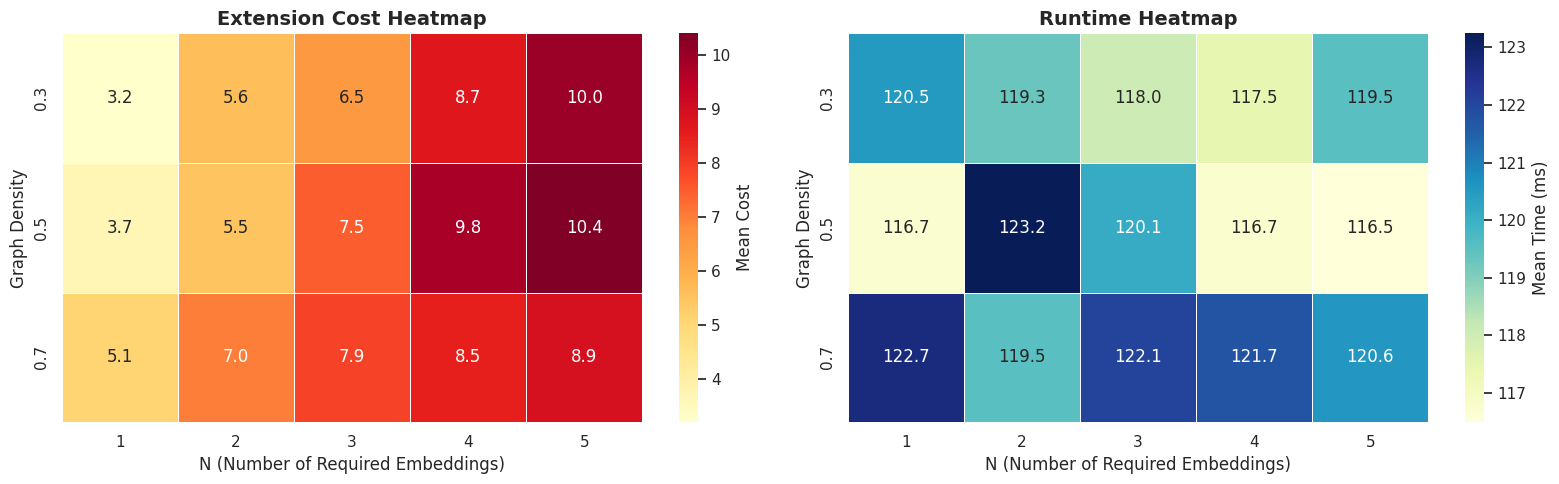

In [9]:
if len(cost_n_df) > 0:
    approx_df = cost_n_df[cost_n_df['algorithm'] == 'approx']
    
    # Create pivot table for heatmap
    pivot_cost = approx_df.pivot_table(values='cost', index='density', columns='n_mappings', aggfunc='mean')
    pivot_time = approx_df.pivot_table(values='time', index='density', columns='n_mappings', aggfunc='mean')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Left: Cost heatmap
    ax1 = axes[0]
    sns.heatmap(pivot_cost, annot=True, fmt='.1f', cmap='YlOrRd', 
                linewidths=0.5, ax=ax1, cbar_kws={'label': 'Mean Cost'})
    ax1.set_title("Extension Cost Heatmap", fontsize=14, fontweight='bold')
    ax1.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
    ax1.set_ylabel("Graph Density", fontsize=12)
    
    # Right: Time heatmap
    ax2 = axes[1]
    sns.heatmap(pivot_time, annot=True, fmt='.1f', cmap='YlGnBu',
                linewidths=0.5, ax=ax2, cbar_kws={'label': 'Mean Time (ms)'})
    ax2.set_title("Runtime Heatmap", fontsize=14, fontweight='bold')
    ax2.set_xlabel("N (Number of Required Embeddings)", fontsize=12)
    ax2.set_ylabel("Graph Density", fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for this visualization.")

### 5.6 Summary Statistics

Key findings from the Cost vs N experiment.

In [10]:
if len(cost_n_df) > 0:
    approx_df = cost_n_df[cost_n_df['algorithm'] == 'approx']
    
    # Summary table
    summary = approx_df.groupby(['density', 'n_mappings']).agg({
        'cost': ['mean', 'std', 'min', 'max'],
        'time': ['mean', 'std']
    }).round(2)
    
    print("=" * 80)
    print("COST VS N EXPERIMENT SUMMARY")
    print("=" * 80)
    print(f"\nGraph Configuration: G={approx_df['size_G'].iloc[0]} vertices, H={approx_df['size_H'].iloc[0]} vertices")
    print(f"Maximum possible disjoint embeddings: {approx_df['size_H'].iloc[0] // approx_df['size_G'].iloc[0]}")
    print(f"\nTotal test cases: {len(approx_df)}")
    print("\n" + "-" * 80)
    print("DETAILED STATISTICS BY DENSITY AND N:")
    print("-" * 80)
    display(summary)
    
    # Key insights
    print("\n" + "=" * 80)
    print("KEY INSIGHTS:")
    print("=" * 80)
    
    # Cost growth rate
    for density in sorted(approx_df['density'].unique()):
        density_df = approx_df[approx_df['density'] == density]
        costs_by_n = density_df.groupby('n_mappings')['cost'].mean()
        
        if len(costs_by_n) > 1:
            growth = (costs_by_n.iloc[-1] - costs_by_n.iloc[0]) / (costs_by_n.index[-1] - costs_by_n.index[0])
            print(f"\n• Density {density}:")
            print(f"  - Cost at N=1: {costs_by_n.iloc[0]:.1f}")
            print(f"  - Cost at N={costs_by_n.index[-1]}: {costs_by_n.iloc[-1]:.1f}")
            print(f"  - Average cost increase per N: {growth:.2f} edges")
else:
    print("No data available. Run the cost_vs_n experiment first.")

COST VS N EXPERIMENT SUMMARY

Graph Configuration: G=5 vertices, H=25 vertices
Maximum possible disjoint embeddings: 5

Total test cases: 150

--------------------------------------------------------------------------------
DETAILED STATISTICS BY DENSITY AND N:
--------------------------------------------------------------------------------


cost                  time       
                    mean   std min max    mean    std
density n_mappings                                   
0.3     1            3.2  3.22   0   7  120.51  14.91
        2            5.6  4.60   0  11  119.34  12.54
        3            6.5  4.95   0  12  118.05  11.74
        4            8.7  4.06   0  13  117.49  11.04
        5           10.0  4.74   0  16  119.55  12.22
0.5     1            3.7  4.57   0  12  116.70  14.69
        2            5.5  6.22   0  16  123.25  21.98
        3            7.5  6.11   0  18  120.12  24.07
        4            9.8  6.94   0  18  116.73  18.17
        5           10.4  7.52   0  20  116.49  18.14
0.7     1            5.1  3.96   0  11  122.70   9.50
        2            7.0  5.73   0  18  119.54   9.20
        3            7.9  6.03   0  18  122.10   9.39
        4            8.5  6.19   0  18  121.75   9.47
        5            8.9  5.76   0  18  120.57   9.91


KEY INSIGHTS:

• Density 0.3:
  - Cost at N=1: 3.2
  - Cost at N=5: 10.0
  - Average cost increase per N: 1.70 edges

• Density 0.5:
  - Cost at N=1: 3.7
  - Cost at N=5: 10.4
  - Average cost increase per N: 1.68 edges

• Density 0.7:
  - Cost at N=1: 5.1
  - Cost at N=5: 8.9
  - Average cost increase per N: 0.95 edges
